# Partis V Gene Misassignment Under Simulated SHM

**Question**: Does realistic SHM (modeled by Thrifty+DASM) cause partis to misassign V genes,
and does this happen more often for real mutations than for simulated ones?

**Setup**:
- 6,990 naive-to-MRCA parent-child pairs from Rodriguez dataset
- 10 DASM-simulated MRCA replicates per PCP (69,900 simulated sequences)
- partis `cache-parameters` with `--leave-default-germline` (fixed OGRDB germline set, no inference)
- Three partis runs: original MRCAs alone, simulated MRCAs alone, and combined (both together)

**Ground truth**: V gene assignments from the original per-subject full-repertoire partis annotation in the PCP file.

In [1]:
import json
import pandas as pd
import numpy as np

BASE = "/home/nharel/re/dasm-epistasis-experiments/_output/partis_output"
SIM_CSV = "/home/nharel/re/dasm-epistasis-experiments/_output/simulated_mrcas.csv.gz"

def load_vj(path):
    """Load uid -> (v_gene, j_gene) from partis cache YAML."""
    with open(path) as f:
        data = json.load(f)
    return {e["unique_ids"][0]: (e["v_gene"], e["j_gene"]) for e in data["events"]}

def gene_only(s):
    """IGHV1-69*01 -> IGHV1-69"""
    return s.rsplit("*", 1)[0] if "*" in s else s

# Load PCP ground truth
sim_df = pd.read_csv(SIM_CSV)
pcp_ref = sim_df.drop_duplicates(subset=["sample_id", "family"])[
    ["sample_id", "family", "v_gene_heavy", "j_gene_heavy"]
].copy()
pcp_ref["family"] = pcp_ref["family"].astype(str)
print(f"PCPs: {len(pcp_ref)}")

# Load partis annotations from all three runs
print("Loading separate-run annotations...")
orig_sw = load_vj(f"{BASE}/original_mrcas_sw-cache.yaml")
orig_hmm = load_vj(f"{BASE}/original_mrcas_parameters/hmm-cache.yaml")
sim_sw = load_vj(f"{BASE}/simulated_mrcas_sw-cache.yaml")
sim_hmm = load_vj(f"{BASE}/simulated_mrcas_parameters/hmm-cache.yaml")

print("Loading combined-run annotations...")
comb_sw = load_vj(f"{BASE}/combined_mrcas_sw-cache.yaml")
comb_hmm = load_vj(f"{BASE}/combined_mrcas_parameters/hmm-cache.yaml")

print(f"Separate: orig_sw={len(orig_sw)}, sim_sw={len(sim_sw)}")
print(f"Combined: {len(comb_sw)} SW, {len(comb_hmm)} HMM")

PCPs: 6990
Loading separate-run annotations...


Loading combined-run annotations...


Separate: orig_sw=6990, sim_sw=69900
Combined: 76890 SW, 76890 HMM


## 0. Simulation validation: mutation distributions

Before analyzing misassignment, confirm that simulated MRCAs have realistic
mutation profiles. These plots compare real naive-to-MRCA mutations (Rodriguez)
against DASM-simulated mutations across all 69,900 simulated sequences.

Filtering PCPs without mutations, or whose ambiguities make them unusable for inference


  5%|▌         | 61/1166 [00:00<00:01, 608.09it/s]

 18%|█▊        | 206/1166 [00:00<00:01, 695.38it/s]

 30%|███       | 353/1166 [00:00<00:01, 717.30it/s]

 43%|████▎     | 501/1166 [00:00<00:00, 727.57it/s]

...

 94%|█████████▍| 1101/1166 [00:01<00:00, 781.33it/s]

 93%|█████████▎| 1090/1166 [00:01<00:00, 738.06it/s]

100%|██████████| 1166/1166 [00:01<00:00, 683.77it/s]


100%|██████████| 1160/1160 [00:01<00:00, 717.28it/s]


Real PCPs: 6990, Simulated (rep 0): 6990
Real:      median=17, mean=19.3
Simulated: median=17, mean=18.6


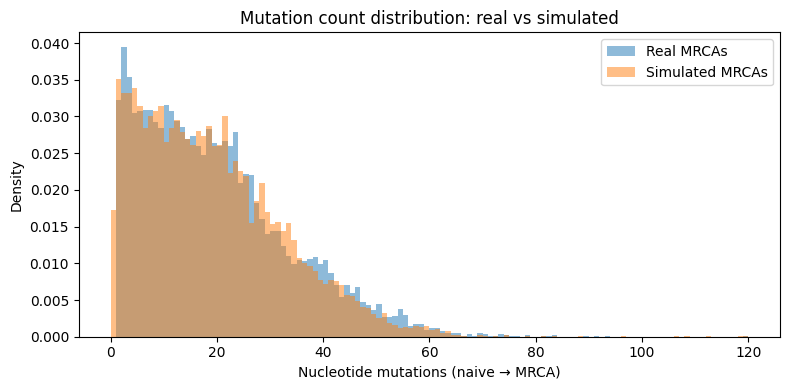

In [2]:
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/home/nharel/re/dasm-epistasis-experiments/germline-misassignment-simulation")
from simulate_mrca import load_naive_to_mrca_pcps, RODRIGUEZ_WITH_NAIVE, RODRIGUEZ_NO_NAIVE
from dnsmex.dxsm_data import filter_valid_pcps

# Load real naive-to-MRCA PCPs
naive_pcps = load_naive_to_mrca_pcps(RODRIGUEZ_WITH_NAIVE, RODRIGUEZ_NO_NAIVE)
for col in ["parent_light", "child_light"]:
    if col not in naive_pcps.columns:
        naive_pcps[col] = ""
naive_pcps = filter_valid_pcps(naive_pcps).reset_index(drop=True)

# Real mutation counts (naive → original MRCA)
naive_pcps["real_muts"] = [
    sum(a != b for a, b in zip(p, c))
    for p, c in zip(naive_pcps["parent_heavy"], naive_pcps["child_heavy"])
]

# Simulated mutation counts (naive → simulated MRCA), one replicate per PCP
sim_rep0 = sim_df[sim_df["replicate"] == 0].copy()
sim_rep0["sim_muts"] = [
    sum(a != b for a, b in zip(p, c))
    for p, c in zip(sim_rep0["naive_heavy"], sim_rep0["simulated_mrca_heavy"])
]

print(f"Real PCPs: {len(naive_pcps)}, Simulated (rep 0): {len(sim_rep0)}")
print(f"Real:      median={naive_pcps['real_muts'].median():.0f}, mean={naive_pcps['real_muts'].mean():.1f}")
print(f"Simulated: median={sim_rep0['sim_muts'].median():.0f}, mean={sim_rep0['sim_muts'].mean():.1f}")

# --- Histogram: mutation count distribution ---
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(0, max(naive_pcps["real_muts"].max(), sim_rep0["sim_muts"].max()) + 2)
ax.hist(naive_pcps["real_muts"], bins=bins, alpha=0.5, label="Real MRCAs", density=True)
ax.hist(sim_rep0["sim_muts"], bins=bins, alpha=0.5, label="Simulated MRCAs", density=True)
ax.set_xlabel("Nucleotide mutations (naive → MRCA)")
ax.set_ylabel("Density")
ax.set_title("Mutation count distribution: real vs simulated")
ax.legend()
plt.tight_layout()
plt.show()

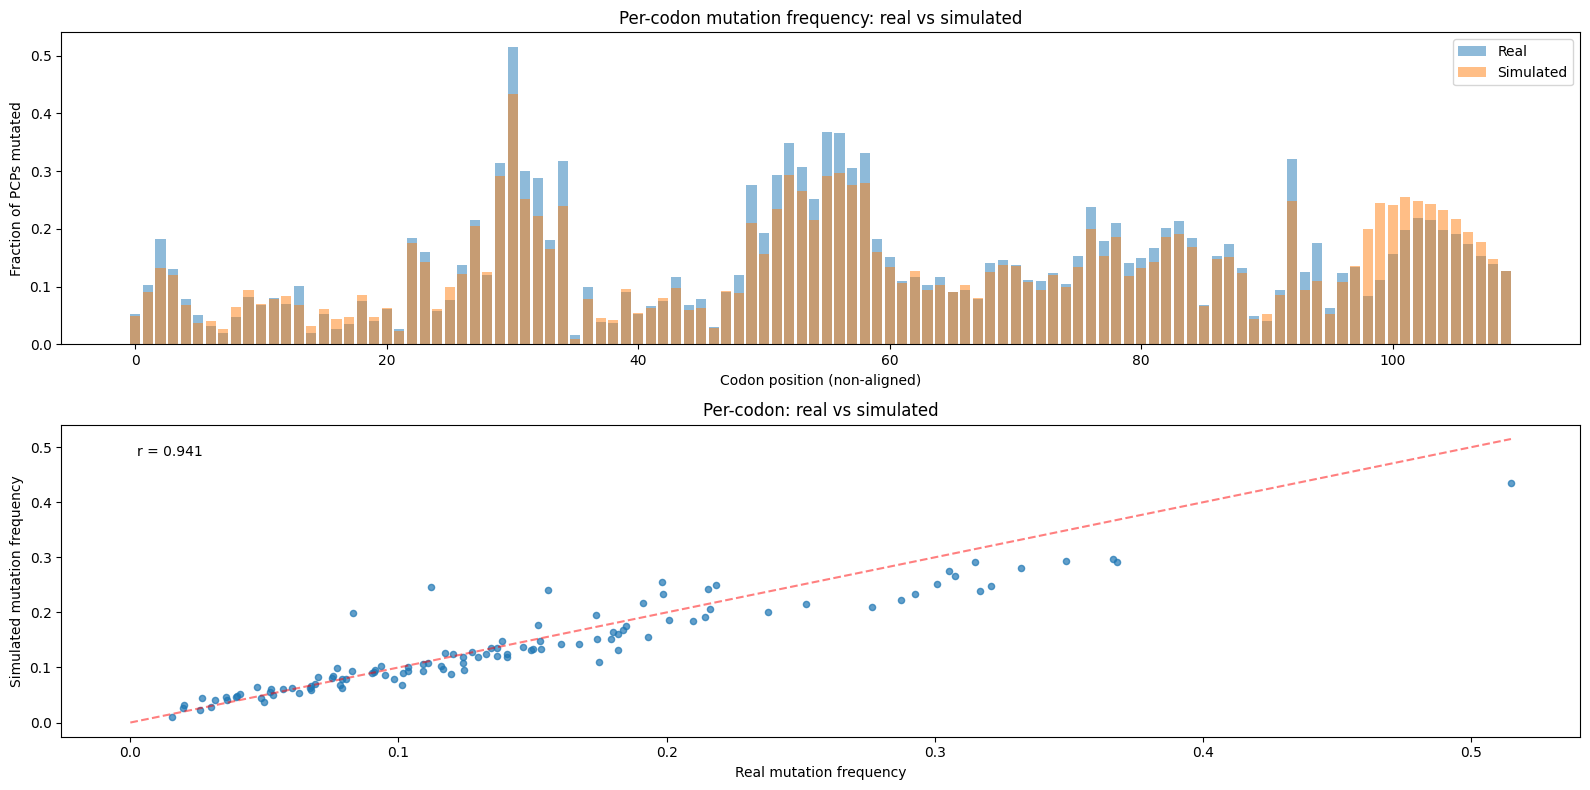

In [3]:
# --- Per-codon mutation frequency: real vs simulated (non-aligned) ---
max_codons = naive_pcps["parent_heavy"].str.len().min() // 3

real_site_freq = np.zeros(max_codons)
sim_site_freq = np.zeros(max_codons)
n_real = np.zeros(max_codons)
n_sim = np.zeros(max_codons)

for _, row in naive_pcps.iterrows():
    naive = row["parent_heavy"]
    mrca = row["child_heavy"]
    n_codons = min(len(naive) // 3, max_codons)
    for c in range(n_codons):
        n_real[c] += 1
        if naive[c*3:(c+1)*3] != mrca[c*3:(c+1)*3]:
            real_site_freq[c] += 1

for _, row in sim_rep0.iterrows():
    naive = row["naive_heavy"]
    sim_seq = row["simulated_mrca_heavy"]
    n_codons = min(len(naive) // 3, max_codons)
    for c in range(n_codons):
        n_sim[c] += 1
        if naive[c*3:(c+1)*3] != sim_seq[c*3:(c+1)*3]:
            sim_site_freq[c] += 1

real_site_freq /= n_real
sim_site_freq /= n_sim

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

ax = axes[0]
ax.bar(range(max_codons), real_site_freq, alpha=0.5, label="Real")
ax.bar(range(max_codons), sim_site_freq, alpha=0.5, label="Simulated")
ax.set_xlabel("Codon position (non-aligned)")
ax.set_ylabel("Fraction of PCPs mutated")
ax.set_title("Per-codon mutation frequency: real vs simulated")
ax.legend()

ax = axes[1]
ax.scatter(real_site_freq, sim_site_freq, s=20, alpha=0.7)
mx = max(real_site_freq.max(), sim_site_freq.max())
ax.plot([0, mx], [0, mx], "r--", alpha=0.5)
ax.set_xlabel("Real mutation frequency")
ax.set_ylabel("Simulated mutation frequency")
ax.set_title("Per-codon: real vs simulated")
corr = np.corrcoef(real_site_freq, sim_site_freq)[0, 1]
ax.text(0.05, 0.9, f"r = {corr:.3f}", transform=ax.transAxes)

plt.tight_layout()
plt.show()

## 1. SW vs HMM: does the annotation method matter?

SW (Smith-Waterman) is purely alignment-based with no learned parameters.
HMM uses per-position mutation rates estimated from the data in each run.

With `--leave-default-germline`, the germline set is fixed, but HMM parameters
differ between runs with different input data.

In [4]:
# SW vs HMM agreement within each separate run
orig_ids = set(orig_sw) & set(orig_hmm)
sw_hmm_orig = sum(1 for s in orig_ids if orig_sw[s][0] == orig_hmm[s][0])

sim_ids = set(sim_sw) & set(sim_hmm)
sw_hmm_sim = sum(1 for s in sim_ids if sim_sw[s][0] == sim_hmm[s][0])

print("SW vs HMM V allele agreement (within same partis run):")
print(f"  Original MRCAs:  {sw_hmm_orig}/{len(orig_ids)} ({sw_hmm_orig/len(orig_ids):.1%})")
print(f"  Simulated MRCAs: {sw_hmm_sim}/{len(sim_ids)} ({sw_hmm_sim/len(sim_ids):.1%})")

# SW vs HMM in combined run
comb_orig_ids = [f"{r['sample_id']}_fam{r['family']}_orig" for _, r in pcp_ref.iterrows()]
comb_orig_ids = [s for s in comb_orig_ids if s in comb_sw and s in comb_hmm]
sw_hmm_comb_orig = sum(1 for s in comb_orig_ids if comb_sw[s][0] == comb_hmm[s][0])
print(f"\n  Combined run (orig seqs): {sw_hmm_comb_orig}/{len(comb_orig_ids)} ({sw_hmm_comb_orig/len(comb_orig_ids):.1%})")

SW vs HMM V allele agreement (within same partis run):
  Original MRCAs:  6623/6990 (94.7%)
  Simulated MRCAs: 67844/69900 (97.1%)



  Combined run (orig seqs): 6734/6990 (96.3%)


## 2. Separate vs combined runs: does SW change?

If SW is purely alignment-based, it should give identical results regardless of
what other sequences are in the run. This confirms there's no confound from
running original and simulated separately.

In [5]:
# Check if SW annotations are identical between separate and combined runs
# Original MRCAs
orig_in_both = [s for s in orig_sw if s in comb_sw]
sw_same_orig = sum(1 for s in orig_in_both if orig_sw[s][0] == comb_sw[s][0])
print(f"Original MRCAs: SW V gene same between separate vs combined run:")
print(f"  {sw_same_orig}/{len(orig_in_both)} ({sw_same_orig/len(orig_in_both):.1%})")

# Simulated MRCAs
sim_in_both = [s for s in sim_sw if s in comb_sw]
sw_same_sim = sum(1 for s in sim_in_both if sim_sw[s][0] == comb_sw[s][0])
print(f"\nSimulated MRCAs: SW V gene same between separate vs combined run:")
print(f"  {sw_same_sim}/{len(sim_in_both)} ({sw_same_sim/len(sim_in_both):.1%})")

# HMM changes more since parameters are learned from different data
hmm_same_orig = sum(1 for s in orig_in_both if orig_hmm.get(s, (None,))[0] == comb_hmm.get(s, (None,))[0])
hmm_same_sim = sum(1 for s in sim_in_both if sim_hmm.get(s, (None,))[0] == comb_hmm.get(s, (None,))[0])
print(f"\nHMM V gene same between separate vs combined:")
print(f"  Original: {hmm_same_orig}/{len(orig_in_both)} ({hmm_same_orig/len(orig_in_both):.1%})")
print(f"  Simulated: {hmm_same_sim}/{len(sim_in_both)} ({hmm_same_sim/len(sim_in_both):.1%})")

Original MRCAs: SW V gene same between separate vs combined run:
  6990/6990 (100.0%)

Simulated MRCAs: SW V gene same between separate vs combined run:
  69900/69900 (100.0%)

HMM V gene same between separate vs combined:
  Original: 6710/6990 (96.0%)
  Simulated: 69654/69900 (99.6%)


## 3. Main comparison: original vs simulated MRCAs vs PCP ground truth

Using SW annotations (no HMM confound) from the combined run for a fair comparison.
Both original and simulated MRCAs were annotated in the same partis run.

In [6]:
# Build comparison dataframe using COMBINED run annotations (both SW and HMM)
rows = []
for _, pcp in pcp_ref.iterrows():
    sid, fam = pcp["sample_id"], pcp["family"]
    pcp_v, pcp_j = pcp["v_gene_heavy"], pcp["j_gene_heavy"]
    orig_id = f"{sid}_fam{fam}_orig"
    
    if orig_id not in comb_sw:
        continue
    
    # Original MRCA
    rows.append({
        "sample_id": sid, "family": fam, "seq_type": "original", "replicate": -1,
        "pcp_v": pcp_v, "pcp_j": pcp_j,
        "sw_v": comb_sw[orig_id][0], "sw_j": comb_sw[orig_id][1],
        "hmm_v": comb_hmm[orig_id][0], "hmm_j": comb_hmm[orig_id][1],
    })
    
    # Simulated replicates
    for rep in range(10):
        sim_id = f"{sid}_fam{fam}_rep{rep}"
        if sim_id in comb_sw:
            rows.append({
                "sample_id": sid, "family": fam, "seq_type": "simulated", "replicate": rep,
                "pcp_v": pcp_v, "pcp_j": pcp_j,
                "sw_v": comb_sw[sim_id][0], "sw_j": comb_sw[sim_id][1],
                "hmm_v": comb_hmm[sim_id][0], "hmm_j": comb_hmm[sim_id][1],
            })

df = pd.DataFrame(rows)

# Compute match columns
for method in ["sw", "hmm"]:
    df[f"{method}_v_allele_match"] = df["pcp_v"] == df[f"{method}_v"]
    df[f"{method}_v_gene_match"] = df["pcp_v"].apply(gene_only) == df[f"{method}_v"].apply(gene_only)
    df[f"{method}_j_allele_match"] = df["pcp_j"] == df[f"{method}_j"]

orig = df[df["seq_type"] == "original"]
sim = df[df["seq_type"] == "simulated"]

print(f"Original MRCAs: {len(orig)}, Simulated: {len(sim)}")
print(f"\n{'':30s} {'V allele':>12s} {'V gene':>12s} {'J allele':>12s}")
print("-" * 70)
for label, sub in [("Original vs PCP (SW)", orig), ("Simulated vs PCP (SW)", sim)]:
    va = sub["sw_v_allele_match"].mean()
    vg = sub["sw_v_gene_match"].mean()
    ja = sub["sw_j_allele_match"].mean()
    print(f"{label:30s} {va:>11.1%} {vg:>11.1%} {ja:>11.1%}")
print()
for label, sub in [("Original vs PCP (HMM)", orig), ("Simulated vs PCP (HMM)", sim)]:
    va = sub["hmm_v_allele_match"].mean()
    vg = sub["hmm_v_gene_match"].mean()
    ja = sub["hmm_j_allele_match"].mean()
    print(f"{label:30s} {va:>11.1%} {vg:>11.1%} {ja:>11.1%}")

Original MRCAs: 6990, Simulated: 69900

                                   V allele       V gene     J allele
----------------------------------------------------------------------
Original vs PCP (SW)                 80.3%       96.0%       99.2%
Simulated vs PCP (SW)                90.5%       99.5%       97.7%

Original vs PCP (HMM)                82.1%       95.9%       96.4%
Simulated vs PCP (HMM)               92.4%       99.5%       98.4%


## 4. Per-PCP paired comparison

For each PCP, compare the original MRCA's match to ground truth vs the simulated
replicates' match rate. This is the cleanest test: same naive parent, same ground truth,
same partis run — only difference is real vs DASM-simulated mutations.

In [7]:
# Per-PCP: does the original MRCA match ground truth, and what fraction of
# simulated replicates match?
pcp_comparison = []
for _, pcp in pcp_ref.iterrows():
    sid, fam, pcp_v = pcp["sample_id"], pcp["family"], pcp["v_gene_heavy"]
    orig_id = f"{sid}_fam{fam}_orig"
    if orig_id not in comb_sw:
        continue
    
    orig_v_match = comb_sw[orig_id][0] == pcp_v
    orig_gene_match = gene_only(comb_sw[orig_id][0]) == gene_only(pcp_v)
    
    sim_matches = []
    sim_gene_matches = []
    for rep in range(10):
        sim_id = f"{sid}_fam{fam}_rep{rep}"
        if sim_id in comb_sw:
            sim_matches.append(comb_sw[sim_id][0] == pcp_v)
            sim_gene_matches.append(gene_only(comb_sw[sim_id][0]) == gene_only(pcp_v))
    
    pcp_comparison.append({
        "sample_id": sid, "family": fam, "pcp_v": pcp_v,
        "orig_v_allele_match": orig_v_match,
        "orig_v_gene_match": orig_gene_match,
        "sim_v_allele_match_rate": np.mean(sim_matches),
        "sim_v_gene_match_rate": np.mean(sim_gene_matches),
        "orig_sw_v": comb_sw[orig_id][0],
    })

pcp_df = pd.DataFrame(pcp_comparison)

# Summary: categorize PCPs
print("Per-PCP V allele match summary (SW, combined run):")
print(f"  Original matches PCP: {pcp_df['orig_v_allele_match'].sum()}/{len(pcp_df)} ({pcp_df['orig_v_allele_match'].mean():.1%})")
print(f"  Simulated match rate (mean): {pcp_df['sim_v_allele_match_rate'].mean():.1%}")
print(f"  Simulated all-10-match: {(pcp_df['sim_v_allele_match_rate'] == 1.0).sum()}/{len(pcp_df)} ({(pcp_df['sim_v_allele_match_rate'] == 1.0).mean():.1%})")
print(f"  Simulated none-match: {(pcp_df['sim_v_allele_match_rate'] == 0.0).sum()}/{len(pcp_df)}")

print(f"\nPer-PCP V gene match summary:")
print(f"  Original matches PCP: {pcp_df['orig_v_gene_match'].sum()}/{len(pcp_df)} ({pcp_df['orig_v_gene_match'].mean():.1%})")
print(f"  Simulated match rate (mean): {pcp_df['sim_v_gene_match_rate'].mean():.1%}")

# Cross-tabulation: original match x simulated match
print("\n--- Cross-tabulation (V allele) ---")
pcp_df["sim_majority_match"] = pcp_df["sim_v_allele_match_rate"] > 0.5
ct = pd.crosstab(
    pcp_df["orig_v_allele_match"].map({True: "orig matches PCP", False: "orig differs"}),
    pcp_df["sim_majority_match"].map({True: "sim majority matches", False: "sim majority differs"}),
)
print(ct)
print(f"\nBoth match: {((pcp_df['orig_v_allele_match']) & (pcp_df['sim_v_allele_match_rate'] > 0.5)).sum()}")
print(f"Orig matches, sim doesn't: {((pcp_df['orig_v_allele_match']) & (pcp_df['sim_v_allele_match_rate'] <= 0.5)).sum()}")
print(f"Sim matches, orig doesn't: {(~pcp_df['orig_v_allele_match'] & (pcp_df['sim_v_allele_match_rate'] > 0.5)).sum()}")
print(f"Neither matches: {(~pcp_df['orig_v_allele_match'] & (pcp_df['sim_v_allele_match_rate'] <= 0.5)).sum()}")

Per-PCP V allele match summary (SW, combined run):
  Original matches PCP: 5613/6990 (80.3%)
  Simulated match rate (mean): 90.5%
  Simulated all-10-match: 4151/6990 (59.4%)
  Simulated none-match: 28/6990

Per-PCP V gene match summary:
  Original matches PCP: 6707/6990 (96.0%)
  Simulated match rate (mean): 99.5%

--- Cross-tabulation (V allele) ---
sim_majority_match   sim majority differs  sim majority matches
orig_v_allele_match                                            
orig differs                          209                  1168
orig matches PCP                      128                  5485

Both match: 5485
Orig matches, sim doesn't: 128
Sim matches, orig doesn't: 1168
Neither matches: 209


## 5. V disagreement breakdown by gene family and allele pair

In [8]:
# Use combined-run SW annotations for clean comparison
# Break down original MRCA disagreements vs simulated disagreements

def disagreement_breakdown(sub_df, label):
    n = len(sub_df)
    v_dis = sub_df[~sub_df["sw_v_allele_match"]].copy()
    v_dis["gene_level"] = v_dis["pcp_v"].apply(gene_only) != v_dis["sw_v"].apply(gene_only)
    n_dis = len(v_dis)
    n_gene = v_dis["gene_level"].sum()
    n_allele = n_dis - n_gene
    
    print(f"\n{label}:")
    print(f"  V allele disagree: {n_dis}/{n} ({n_dis/n:.1%})")
    print(f"    Gene-level: {n_gene} ({n_gene/max(n_dis,1):.1%})")
    print(f"    Allele-only: {n_allele} ({n_allele/max(n_dis,1):.1%})")
    
    print(f"\n  Top allele-only (PCP -> SW):")
    allele_dis = v_dis[~v_dis["gene_level"]]
    for (pcp_v, sw_v), cnt in allele_dis.groupby(["pcp_v", "sw_v"]).size().sort_values(ascending=False).head(10).items():
        print(f"    {pcp_v} -> {sw_v}: {cnt}")
    
    print(f"\n  Top gene-level (PCP -> SW):")
    gene_dis = v_dis[v_dis["gene_level"]]
    for (pcp_v, sw_v), cnt in gene_dis.groupby(["pcp_v", "sw_v"]).size().sort_values(ascending=False).head(10).items():
        print(f"    {pcp_v} -> {sw_v}: {cnt}")

disagreement_breakdown(orig, "Original MRCAs")
disagreement_breakdown(sim, "Simulated MRCAs")


Original MRCAs:
  V allele disagree: 1377/6990 (19.7%)
    Gene-level: 283 (20.6%)
    Allele-only: 1094 (79.4%)

  Top allele-only (PCP -> SW):
    IGHV1-69*01 -> IGHV1-69*06: 59
    IGHV1-69*01 -> IGHV1-69*12: 43
    IGHV1-18*01 -> IGHV1-18*04: 38
    IGHV1-3*01 -> IGHV1-3*04: 38
    IGHV4-39*07 -> IGHV4-39*01: 34
    IGHV1-69*01 -> IGHV1-69*17: 33
    IGHV5-51*01 -> IGHV5-51*03: 30
    IGHV4-39*01 -> IGHV4-39*08: 29
    IGHV3-7*01 -> IGHV3-7*04: 28
    IGHV3-23*01 -> IGHV3-23*04: 26

  Top gene-level (PCP -> SW):
    IGHV3-33*01 -> IGHV3-30*18: 62
    IGHV4-59*01 -> IGHV4-NL1*01: 35
    IGHV4-31*03 -> IGHV4-30-4*01: 19
    IGHV3-30*18 -> IGHV3-30-3*01: 17
    IGHV3-30*18 -> IGHV3-33*01: 16
    IGHV3-33*01 -> IGHV3-30*03: 13
    IGHV3-53*01 -> IGHV3-66*01: 12
    IGHV3-30*03 -> IGHV3-33*01: 10
    IGHV3-30-3*01 -> IGHV3-30*18: 9
    IGHV4-30-4*01 -> IGHV4-31*03: 7

Simulated MRCAs:
  V allele disagree: 6615/69900 (9.5%)
    Gene-level: 375 (5.7%)
    Allele-only: 6240 (94.3%)

  Top

In [9]:
# Match rates by V family (combined run SW)
print(f"{'Family':>8s}  {'Orig allele':>12s} {'Orig gene':>12s} {'Sim allele':>12s} {'Sim gene':>12s} {'n PCPs':>8s}")
print("-" * 70)

df["v_family"] = df["pcp_v"].str.extract(r"(IGHV\d+)")
for fam in sorted(df["v_family"].dropna().unique()):
    o = orig[orig["pcp_v"].str.contains(fam, na=False)]
    s = sim[sim["pcp_v"].str.contains(fam, na=False)]
    n_pcps = len(o)
    print(f"{fam:>8s}  {o['sw_v_allele_match'].mean():>11.1%} {o['sw_v_gene_match'].mean():>11.1%} "
          f"{s['sw_v_allele_match'].mean():>11.1%} {s['sw_v_gene_match'].mean():>11.1%} {n_pcps:>8d}")

  Family   Orig allele    Orig gene   Sim allele     Sim gene   n PCPs
----------------------------------------------------------------------


   IGHV1        70.0%       99.9%       83.4%      100.0%     1455
   IGHV2        82.7%       94.2%       93.9%       99.8%      208
   IGHV3        81.9%       94.0%       92.3%       99.3%     3156
   IGHV4        84.1%       95.4%       91.0%       99.2%     1731
   IGHV5        81.8%      100.0%       97.6%      100.0%      313
   IGHV6       100.0%      100.0%      100.0%      100.0%       83
   IGHV7       100.0%      100.0%       98.0%      100.0%       44


## 6. Key question: is the difference in match rates real or an artifact?

The PCP "ground truth" V gene comes from per-subject full-repertoire partis
annotation with germline inference. Our single-sequence annotation uses
`--leave-default-germline` (full OGRDB set, no pruning).

The disagreements between PCP and our annotation could reflect:
1. Genuine misassignment from SHM mutations  
2. Different germline sets (OGRDB vs per-subject inferred)  
3. Full-repertoire context that helps partis distinguish close alleles

To separate these, look at **which PCPs disagree** — if it's the same PCPs
for original and simulated, the disagreement is from the annotation setup,
not from SHM.

In [10]:
# For PCPs where the original MRCA DOES match PCP ground truth,
# how often do simulated replicates also match?
# This isolates the SHM effect: same PCP, same partis run, but different mutations.

orig_matches = pcp_df[pcp_df["orig_v_allele_match"]]
orig_not = pcp_df[~pcp_df["orig_v_allele_match"]]

print("Among PCPs where original MRCA matches PCP V allele:")
print(f"  N = {len(orig_matches)}")
print(f"  Simulated match rate: {orig_matches['sim_v_allele_match_rate'].mean():.1%}")
print(f"  Simulated all-10 match: {(orig_matches['sim_v_allele_match_rate'] == 1.0).sum()}/{len(orig_matches)} ({(orig_matches['sim_v_allele_match_rate'] == 1.0).mean():.1%})")
print(f"  Simulated none match: {(orig_matches['sim_v_allele_match_rate'] == 0.0).sum()}/{len(orig_matches)}")

print(f"\nAmong PCPs where original MRCA DIFFERS from PCP V allele:")
print(f"  N = {len(orig_not)}")
print(f"  Simulated match rate: {orig_not['sim_v_allele_match_rate'].mean():.1%}")
print(f"  Simulated all-10 match: {(orig_not['sim_v_allele_match_rate'] == 1.0).sum()}/{len(orig_not)}")
print(f"  Simulated none match: {(orig_not['sim_v_allele_match_rate'] == 0.0).sum()}/{len(orig_not)}")

# Same for gene level
orig_gene_matches = pcp_df[pcp_df["orig_v_gene_match"]]
orig_gene_not = pcp_df[~pcp_df["orig_v_gene_match"]]

print(f"\n--- Gene level ---")
print(f"Orig gene matches PCP ({len(orig_gene_matches)}): sim gene match rate = {orig_gene_matches['sim_v_gene_match_rate'].mean():.1%}")
print(f"Orig gene differs ({len(orig_gene_not)}): sim gene match rate = {orig_gene_not['sim_v_gene_match_rate'].mean():.1%}")

Among PCPs where original MRCA matches PCP V allele:
  N = 5613
  Simulated match rate: 93.2%
  Simulated all-10 match: 3684/5613 (65.6%)
  Simulated none match: 0/5613

Among PCPs where original MRCA DIFFERS from PCP V allele:
  N = 1377
  Simulated match rate: 79.6%
  Simulated all-10 match: 467/1377
  Simulated none match: 28/1377

--- Gene level ---
Orig gene matches PCP (6707): sim gene match rate = 99.7%
Orig gene differs (283): sim gene match rate = 94.7%


## 7. Direct original-vs-simulated comparison (ignoring PCP ground truth)

The cleanest misassignment test: for each PCP, does partis assign the same V gene
to the original MRCA as to the simulated MRCA? Both annotated in the same combined run.
Disagreements here mean that mutations (real vs simulated) caused a different assignment.

In [11]:
# Original vs simulated: direct comparison (combined run SW)
orig_vs_sim = []
for _, pcp in pcp_ref.iterrows():
    sid, fam = pcp["sample_id"], pcp["family"]
    orig_id = f"{sid}_fam{fam}_orig"
    if orig_id not in comb_sw:
        continue
    orig_v = comb_sw[orig_id][0]
    
    for rep in range(10):
        sim_id = f"{sid}_fam{fam}_rep{rep}"
        if sim_id in comb_sw:
            sim_v = comb_sw[sim_id][0]
            orig_vs_sim.append({
                "sample_id": sid, "family": fam, "replicate": rep,
                "pcp_v": pcp["v_gene_heavy"],
                "orig_v": orig_v, "sim_v": sim_v,
                "allele_match": orig_v == sim_v,
                "gene_match": gene_only(orig_v) == gene_only(sim_v),
            })

ovs = pd.DataFrame(orig_vs_sim)
n = len(ovs)
print(f"Original vs Simulated MRCA (combined run SW):")
print(f"  V allele match: {ovs['allele_match'].sum()}/{n} ({ovs['allele_match'].mean():.1%})")
print(f"  V gene match:   {ovs['gene_match'].sum()}/{n} ({ovs['gene_match'].mean():.1%})")

# Per-PCP: what fraction of replicates agree with original
ovs_pcp = ovs.groupby(["sample_id", "family"]).agg(
    allele_agree_rate=("allele_match", "mean"),
    gene_agree_rate=("gene_match", "mean"),
    pcp_v=("pcp_v", "first"),
    orig_v=("orig_v", "first"),
).reset_index()

print(f"\nPer-PCP original-vs-simulated agreement (V allele):")
print(f"  All 10 agree: {(ovs_pcp['allele_agree_rate'] == 1.0).sum()}/{len(ovs_pcp)} ({(ovs_pcp['allele_agree_rate'] == 1.0).mean():.1%})")
print(f"  None agree: {(ovs_pcp['allele_agree_rate'] == 0.0).sum()}/{len(ovs_pcp)}")
print(f"  Mean rate: {ovs_pcp['allele_agree_rate'].mean():.1%}")

# Top disagreements
v_dis = ovs[~ovs["allele_match"]]
print(f"\nTop orig->sim allele disagreements:")
for (o, s), cnt in v_dis.groupby(["orig_v", "sim_v"]).size().sort_values(ascending=False).head(10).items():
    print(f"  {o} -> {s}: {cnt}")

Original vs Simulated MRCA (combined run SW):
  V allele match: 53252/69900 (76.2%)
  V gene match:   66948/69900 (95.8%)

Per-PCP original-vs-simulated agreement (V allele):
  All 10 agree: 3694/6990 (52.8%)
  None agree: 924/6990
  Mean rate: 76.2%

Top orig->sim allele disagreements:
  IGHV3-30*18 -> IGHV3-33*01: 460
  IGHV1-69*06 -> IGHV1-69*01: 405
  IGHV1-18*04 -> IGHV1-18*01: 379
  IGHV4-39*01 -> IGHV4-39*07: 338
  IGHV5-51*03 -> IGHV5-51*01: 294
  IGHV4-59*01 -> IGHV4-59*11: 288
  IGHV3-7*01 -> IGHV3-7*03: 287
  IGHV4-NL1*01 -> IGHV4-59*01: 276
  IGHV3-23*04 -> IGHV3-23*01: 272
  IGHV1-3*04 -> IGHV1-3*01: 269


## 8. Per-site germline amino acid misassignment rate

When partis assigns the wrong V allele, the germline amino acid annotation is wrong
at every site where the true and assigned alleles differ. This quantifies how often
each site's germline amino acid is wrong due to allele misassignment.

For each simulated MRCA:
1. Compare true V allele (PCP) to SW-assigned V allele
2. When they differ, look up both alleles in the Chothia germline codon table
3. At sites where the alleles have different amino acids, the germline is wrong
4. Aggregate: per (family, site, amino acid), what fraction of sequences have a
   wrong germline annotation?

In [12]:
# Load germline codon table
gc = pd.read_csv("/home/nharel/re/dasm-epistasis-experiments/germline/germline_codons_chothia.csv")

# Build lookup: (v_allele, site) -> amino_acid
allele_site_aa = {}
for _, row in gc.iterrows():
    allele_site_aa[(row["v_gene"], row["site"])] = row["amino_acid"]

# Get all sites in the table
all_sites = sorted(gc["site"].unique())

# Build v_family lookup from gc table
allele_to_family = gc.drop_duplicates("v_gene").set_index("v_gene")["v_family"].to_dict()

# For each simulated MRCA, track:
# - total sequences per (v_family, site, true_aa)
# - wrong germline count per (v_family, site, true_aa)
# - what the wrong AA is per (v_family, site, true_aa, assigned_aa)
from collections import Counter
site_totals = Counter()  # (v_family, site, true_aa) -> count
site_wrong = Counter()   # (v_family, site, true_aa) -> count of wrong germline
site_wrong_to = Counter()  # (v_family, site, true_aa, assigned_aa) -> count

for _, row in sim.iterrows():
    pcp_v = row["pcp_v"]
    sw_v = row["sw_v"]
    v_family = allele_to_family.get(pcp_v)
    if v_family is None:
        continue
    
    for site in all_sites:
        true_aa = allele_site_aa.get((pcp_v, site))
        if true_aa is None:
            continue
        site_totals[(v_family, site, true_aa)] += 1
        
        if pcp_v != sw_v:
            assigned_aa = allele_site_aa.get((sw_v, site))
            if assigned_aa is not None and assigned_aa != true_aa:
                site_wrong[(v_family, site, true_aa)] += 1
                site_wrong_to[(v_family, site, true_aa, assigned_aa)] += 1

print(f"Processed {len(sim)} simulated sequences")
print(f"Total (family, site, aa) entries: {len(site_totals)}")
print(f"Entries with any wrong germline: {len(site_wrong)}")

Processed 69900 simulated sequences
Total (family, site, aa) entries: 981
Entries with any wrong germline: 150


In [13]:
# Build results table with per-site misassignment rates, broken down by V family
results = []
for (v_family, site, true_aa), total in site_totals.items():
    wrong = site_wrong.get((v_family, site, true_aa), 0)
    results.append({
        "v_family": v_family,
        "site": site,
        "germline_aa": true_aa,
        "total_seqs": total,
        "wrong_germline": wrong,
        "wrong_pct": 100 * wrong / total,
    })

result_df = pd.DataFrame(results).sort_values(["v_family", "wrong_pct"], ascending=[True, False])

# Per-family summary and top sites
for fam in sorted(result_df["v_family"].unique()):
    fam_df = result_df[result_df["v_family"] == fam]
    fam_with_errors = fam_df[fam_df["wrong_germline"] > 0]
    total_seqs_fam = fam_df.drop_duplicates("total_seqs")["total_seqs"].sum()  # rough
    
    print(f"\n{'='*65}")
    print(f"{fam}")
    print(f"  Sites with >0% error: {len(fam_with_errors)} / {len(fam_df)}")
    print(f"{'='*65}")
    
    if len(fam_with_errors) == 0:
        print("  (no misassignment errors)")
        continue
    
    print(f"{'Site':>6s} {'AA':>4s} {'Wrong%':>8s} {'Wrong':>7s} {'Total':>7s}")
    print("-" * 38)
    for _, r in fam_with_errors.head(15).iterrows():
        print(f"{r['site']:>6} {r['germline_aa']:>4s} {r['wrong_pct']:>7.1f}% {r['wrong_germline']:>7d} {r['total_seqs']:>7d}")


IGHV1
  Sites with >0% error: 36 / 201
  Site   AA   Wrong%   Wrong   Total
--------------------------------------
    73    E    16.7%     664    3980
    33    T    11.8%      26     220
    50    G    11.7%     534    4560
    54    L     9.7%      59     610
    66    W     8.6%      12     140
    56    T     8.3%     337    4070
   52A    A     8.3%     312    3780
    50    R     2.7%      40    1490
   52A    T     2.3%       3     130
    34    V     1.8%       2     110
    73    K     1.6%      11     700
    56    I     1.5%       9     610
    50    W     1.2%      84    6890
    54    F     1.2%      49    4070
    66    R     0.6%      83   14410

IGHV2
  Sites with >0% error: 12 / 127
  Site   AA   Wrong%   Wrong   Total
--------------------------------------
    54    D     4.4%      73    1670
    54    N     3.4%      14     410
    50    R     2.3%       8     350
    33    R     1.5%       2     130
    58    F     1.5%       2     130
    37    I     0.8%      17

## 8b. What germline AA gets assigned instead?

When the germline is wrong at a site, what amino acid does partis think
is germline? This shows the true→assigned substitution for each
(family, site) combination, so we can see exactly what the misassignment
looks like at the amino acid level.

In [14]:
# Build table: when germline is wrong, what AA gets assigned instead?
wrong_to_rows = []
for (v_family, site, true_aa, assigned_aa), count in site_wrong_to.items():
    total = site_totals[(v_family, site, true_aa)]
    wrong_to_rows.append({
        "v_family": v_family,
        "site": site,
        "true_aa": true_aa,
        "assigned_aa": assigned_aa,
        "count": count,
        "total_seqs": total,
        "wrong_pct": 100 * count / total,
    })

wrong_to_df = pd.DataFrame(wrong_to_rows).sort_values(
    ["v_family", "wrong_pct"], ascending=[True, False]
)

for fam in sorted(wrong_to_df["v_family"].unique()):
    fam_df = wrong_to_df[wrong_to_df["v_family"] == fam]
    
    print(f"\n{'='*70}")
    print(f"{fam} — germline misassignment: true AA → assigned AA")
    print(f"{'='*70}")
    print(f"{'Site':>6s} {'True':>5s} {'→':>2s} {'Assigned':>9s} {'Wrong%':>8s} {'Count':>7s} {'Total':>7s}")
    print("-" * 50)
    for _, r in fam_df.head(20).iterrows():
        print(f"{r['site']:>6} {r['true_aa']:>5s}  → {r['assigned_aa']:>6s}   {r['wrong_pct']:>7.1f}% {r['count']:>7d} {r['total_seqs']:>7d}")


IGHV1 — germline misassignment: true AA → assigned AA
  Site  True  →  Assigned   Wrong%   Count   Total
--------------------------------------------------
    73     E  →      K      16.7%     663    3980
    33     T  →      A      11.8%      26     220
    50     G  →      R      11.7%     533    4560
    54     L  →      F       9.7%      59     610
    66     W  →      R       8.6%      12     140
    56     T  →      I       8.3%     336    4070
   52A     A  →      T       8.3%     312    3780
   52A     T  →      A       2.3%       3     130
    34     V  →      M       1.8%       2     110
    50     R  →      W       1.7%      26    1490
    73     K  →      E       1.6%      11     700
    56     I  →      T       1.5%       9     610
    50     W  →      R       1.2%      84    6890
    54     F  →      L       1.2%      48    4070
    50     R  →      G       0.9%      14    1490
    66     R  →      W       0.6%      83   14410
    61     Q  →      H       0.5%      75  

## 9. Contamination analysis

The entrenchment analysis groups sequences by their assigned germline AA at each
site and looks at substitution rates away from that AA. The relevant question is:
of all sequences **assigned** a given germline AA at a site, what fraction actually
have a different true germline?

This is the contamination rate for the pool we use in the analysis. A high rate at
an entrenched site would mean the substitution signal is diluted by sequences whose
true germline is different from what we think.

In [15]:
# Contamination analysis: for each (v_family, site, assigned_aa),
# what fraction of sequences have a different true germline AA?
#
# Denominator: all simulated sequences where SW assigns an allele with AA=X at site S
# Numerator: those where the true (PCP) allele has a different AA at site S

assigned_totals = Counter()    # (v_family, site, assigned_aa) -> count
assigned_wrong = Counter()     # (v_family, site, assigned_aa) -> count where true AA differs
assigned_wrong_from = Counter() # (v_family, site, assigned_aa, true_aa) -> count

for _, row in sim.iterrows():
    pcp_v = row["pcp_v"]
    sw_v = row["sw_v"]
    v_family = allele_to_family.get(pcp_v)
    if v_family is None:
        continue
    
    for site in all_sites:
        assigned_aa = allele_site_aa.get((sw_v, site))
        true_aa = allele_site_aa.get((pcp_v, site))
        if assigned_aa is None or true_aa is None:
            continue
        
        assigned_totals[(v_family, site, assigned_aa)] += 1
        if true_aa != assigned_aa:
            assigned_wrong[(v_family, site, assigned_aa)] += 1
            assigned_wrong_from[(v_family, site, assigned_aa, true_aa)] += 1

print(f"Total (family, site, assigned_aa) entries: {len(assigned_totals)}")
print(f"Entries with any contamination: {len(assigned_wrong)}")

Total (family, site, assigned_aa) entries: 993
Entries with any contamination: 164


In [16]:
# Per-family contamination rates
contam_rows = []
for (v_family, site, assigned_aa), total in assigned_totals.items():
    wrong = assigned_wrong.get((v_family, site, assigned_aa), 0)
    contam_rows.append({
        "v_family": v_family,
        "site": site,
        "assigned_aa": assigned_aa,
        "total_assigned": total,
        "n_contaminated": wrong,
        "contam_pct": 100 * wrong / total,
    })

contam_df = pd.DataFrame(contam_rows).sort_values(["v_family", "contam_pct"], ascending=[True, False])

for fam in sorted(contam_df["v_family"].unique()):
    fam_df = contam_df[contam_df["v_family"] == fam]
    fam_contam = fam_df[fam_df["n_contaminated"] > 0]
    
    print(f"\n{'='*70}")
    print(f"{fam} — contamination of assigned germline AA pools")
    print(f"  Pools with >0% contamination: {len(fam_contam)} / {len(fam_df)}")
    print(f"{'='*70}")
    
    if len(fam_contam) == 0:
        print("  (no contamination)")
        continue
    
    print(f"{'Site':>6s} {'Assigned':>9s} {'Contam%':>9s} {'Wrong':>7s} {'Total':>7s}")
    print("-" * 44)
    for _, r in fam_contam.iterrows():
        print(f"{r['site']:>6} {r['assigned_aa']:>9s} {r['contam_pct']:>8.1f}% {r['n_contaminated']:>7d} {r['total_assigned']:>7d}")



IGHV1 — contamination of assigned germline AA pools
  Pools with >0% contamination: 40 / 204
  Site  Assigned   Contam%   Wrong   Total
--------------------------------------------
    61         H    100.0%      75      75
    11         E    100.0%       8       8
    88         V    100.0%       1       1
   52A         T     71.1%     312     439
    73         K     49.0%     663    1352
    87         M     41.2%       7      17
    66         W     39.3%      83     211
    56         I     35.9%     336     937
    50         R     29.9%     617    2067
    33         T     10.2%      22     216
    54         L      8.0%      48     599
    54         F      1.4%      59    4080
    63         L      0.6%      16    2466
    33         A      0.4%      26    6033
    50         W      0.4%      27    6833
    71         T      0.4%       9    2459
    50         G      0.3%      14    4040
    73         E      0.3%      11    3327
    56         T      0.2%       9    3742
 

In [17]:
# Breakdown: for contaminated pools, what are the true AAs?
contam_detail_rows = []
for (v_family, site, assigned_aa, true_aa), count in assigned_wrong_from.items():
    total = assigned_totals[(v_family, site, assigned_aa)]
    contam_detail_rows.append({
        "v_family": v_family,
        "site": site,
        "assigned_aa": assigned_aa,
        "true_aa": true_aa,
        "count": count,
        "total_assigned": total,
        "contam_pct": 100 * count / total,
    })

contam_detail_df = pd.DataFrame(contam_detail_rows).sort_values(
    ["v_family", "contam_pct"], ascending=[True, False]
)

for fam in sorted(contam_detail_df["v_family"].unique()):
    fam_df = contam_detail_df[contam_detail_df["v_family"] == fam]
    
    print(f"\n{'='*70}")
    print(f"{fam} — contamination detail: assigned AA ← true AA")
    print(f"{'='*70}")
    print(f"{'Site':>6s} {'Assigned':>9s} {'←':>2s} {'True':>5s}  {'Contam%':>9s} {'Count':>7s} {'Total':>7s}")
    print("-" * 53)
    for _, r in fam_df.head(20).iterrows():
        print(f"{r['site']:>6} {r['assigned_aa']:>9s}  ← {r['true_aa']:>4s}  {r['contam_pct']:>8.1f}% {r['count']:>7d} {r['total_assigned']:>7d}")


IGHV1 — contamination detail: assigned AA ← true AA
  Site  Assigned  ←  True    Contam%   Count   Total
-----------------------------------------------------
    61         H  ←    Q     100.0%      75      75
    11         E  ←    V     100.0%       8       8
    88         V  ←    A     100.0%       1       1
   52A         T  ←    A      71.1%     312     439
    73         K  ←    E      49.0%     663    1352
    87         M  ←    T      41.2%       7      17
    66         W  ←    R      39.3%      83     211
    56         I  ←    T      35.9%     336     937
    50         R  ←    G      25.8%     533    2067
    33         T  ←    A      10.2%      22     216
    54         L  ←    F       8.0%      48     599
    50         R  ←    W       4.1%      84    2067
    54         F  ←    L       1.4%      59    4080
    63         L  ←    F       0.6%      16    2466
    33         A  ←    T       0.4%      26    6033
    50         W  ←    R       0.4%      26    6833
    71  

## 9b. Contamination at entrenched sites

Cross-reference the contamination rates with the actual entrenched site/AA pairs
from the entrenchment analysis. For each entrenched substitution X→Y, how
contaminated is the "assigned X" pool?

In [18]:
# Load entrenched sites and look up contamination rates
entrenched = pd.read_csv("/home/nharel/re/dasm-epistasis-experiments/_output/combined_entrenched_sites.csv")

# Build lookup from contamination analysis
contam_lookup = {}
for (v_family, site, assigned_aa), total in assigned_totals.items():
    wrong = assigned_wrong.get((v_family, site, assigned_aa), 0)
    contam_lookup[(v_family, str(site), assigned_aa)] = {
        "total": total, "wrong": wrong, "pct": 100 * wrong / total
    }

# Also build the detail lookup for what the true AAs are
contam_detail_lookup = {}
for (v_family, site, assigned_aa, true_aa), count in assigned_wrong_from.items():
    total = assigned_totals[(v_family, site, assigned_aa)]
    key = (v_family, str(site), assigned_aa)
    if key not in contam_detail_lookup:
        contam_detail_lookup[key] = []
    contam_detail_lookup[key].append((true_aa, count, 100 * count / total))

# For each entrenched pair, look up the contamination of the parent AA pool
rows = []
for _, row in entrenched.iterrows():
    fam, site, aa, target, source, etype = row["v_family"], str(row["site"]), row["amino_acid"], row["target_amino_acid"], row["source"], row["type"]
    key = (fam, site, aa)
    info = contam_lookup.get(key, {"total": 0, "wrong": 0, "pct": 0})
    detail = contam_detail_lookup.get(key, [])
    detail_str = ", ".join(f"{t[0]}:{t[2]:.1f}%" for t in sorted(detail, key=lambda x: -x[2])) if detail else "—"
    rows.append({
        "v_family": fam, "site": site, "parent_aa": aa, "target_aa": target,
        "type": etype, "source": source,
        "pool_size": info["total"], "contam_pct": info["pct"],
        "contam_detail": detail_str,
    })

entrenched_contam = pd.DataFrame(rows)

# Show within-family first, then between-family, separated by V family
for etype in ["within", "between"]:
    sub = entrenched_contam[entrenched_contam["type"] == etype].copy()
    sub = sub.sort_values(["v_family", "site", "parent_aa", "target_aa"])
    
    for fam in sorted(sub["v_family"].unique()):
        fam_sub = sub[sub["v_family"] == fam]
        print(f"\n{'='*90}")
        print(f"{fam} — Entrenched pairs — {etype}-family")
        print(f"{'='*90}")
        print(f"{'Site':>5s} {'Parent':>7s} {'→Target':>8s} {'Pool':>7s} {'Contam%':>9s}  {'True AAs (contam detail)'}")
        print("-" * 70)
        for _, r in fam_sub.iterrows():
            print(f"{r['site']:>5s} {r['parent_aa']:>7s} {'→'+r['target_aa']:>8s} {r['pool_size']:>7d} {r['contam_pct']:>8.1f}%  {r['contam_detail']}")



IGHV1 — Entrenched pairs — within-family
 Site  Parent  →Target    Pool   Contam%  True AAs (contam detail)
----------------------------------------------------------------------
   33       A       →D    6033      0.4%  T:0.4%
   33       D       →A     740      0.0%  —
   33       D       →G     740      0.0%  —
   33       D       →Y     740      0.0%  —
   33       G       →D    2450      0.0%  —
   33       S       →Y     750      0.0%  —
   33       Y       →D    4361      0.0%  A:0.0%
   33       Y       →S    4361      0.0%  A:0.0%
   50       G       →W    4040      0.3%  R:0.3%
   50       R       →W    2067     29.9%  G:25.8%, W:4.1%
   50       W       →G    6833      0.4%  R:0.4%, G:0.0%
   50       W       →R    6833      0.4%  R:0.4%, G:0.0%
   52       D       →V    1000      0.0%  —
   52       I       →S    4679      0.0%  —
   52       S       →I    2450      0.0%  —
   52       V       →D     110      0.0%  —

IGHV3 — Entrenched pairs — within-family
 Site  Parent 

## 10. Which alleles cause the top contaminated entrenched pools?

For the three entrenched pools with >5% contamination, identify which allele pairs are responsible and their nucleotide differences.

In [19]:
from Bio.Seq import Seq

# Load germline nucleotide sequences
gl_fasta = f"{BASE}/simulated_mrcas_parameters/sw/germline-sets/igh/ighv.fasta"
gl_seqs = {}
with open(gl_fasta) as f:
    name, seq = None, []
    for line in f:
        if line.startswith(">"):
            if name: gl_seqs[name] = "".join(seq)
            name = line.strip().lstrip(">"); seq = []
        else: seq.append(line.strip())
    if name: gl_seqs[name] = "".join(seq)

# Load germline codon table for Chothia site numbering
gc = pd.read_csv("/home/nharel/re/dasm-epistasis-experiments/germline/germline_codons_chothia.csv")
allele_chothia_aa = {}
for _, row in gc.iterrows():
    allele_chothia_aa[(row["v_gene"], str(row["site"]))] = row["amino_acid"]

# The 3 entrenched pools with >5% contamination
problem_pools = [
    ("IGHV1", "73", "K", "E"),  # 49.0% — between-family K->N
    ("IGHV1", "50", "R", "G"),  # 29.9% (25.8% G, 4.1% W) — within R->W, between R->G,S
    ("IGHV4", "29", "V", "I"),  # 10.8% — between-family V->F
]

for v_family, site, assigned_aa, main_true_aa in problem_pools:
    print(f"\n{'='*90}")
    print(f"{v_family} site {site} — assigned {assigned_aa}, contaminated by {main_true_aa}")
    print(f"{'='*90}")
    
    # Find misassignment pairs that cause this contamination
    # A sequence with true allele X gets assigned allele Y where:
    #   - allele X has main_true_aa at this site
    #   - allele Y has assigned_aa at this site
    pair_counts = sim.groupby(["pcp_v", "sw_v"]).size().reset_index(name="count")
    pair_counts = pair_counts[pair_counts["pcp_v"] != pair_counts["sw_v"]]
    
    contributing = []
    for _, row in pair_counts.iterrows():
        pcp_v, sw_v, count = row["pcp_v"], row["sw_v"], row["count"]
        true_aa_at_site = allele_chothia_aa.get((pcp_v, site))
        assigned_aa_at_site = allele_chothia_aa.get((sw_v, site))
        if true_aa_at_site == main_true_aa and assigned_aa_at_site == assigned_aa:
            contributing.append((pcp_v, sw_v, count))
    
    contributing.sort(key=lambda x: -x[2])
    
    print(f"\n{'True allele':<25s} {'Assigned allele':<25s} {'Count':>6s}  Nucleotide differences")
    print("-" * 100)
    
    seen_pairs = set()
    for pcp_v, sw_v, count in contributing:
        pair_key = tuple(sorted([pcp_v, sw_v]))
        
        # Compute nt diffs
        s1, s2 = gl_seqs.get(pcp_v, ""), gl_seqs.get(sw_v, "")
        diff_str = "?"
        if s1 and s2:
            minlen = min(len(s1), len(s2))
            diffs = []
            for i in range(minlen):
                if s1[i] != s2[i] and s1[i] != '.' and s2[i] != '.':
                    ci = i // 3
                    c1 = s1[ci*3:ci*3+3].replace('.','N')
                    c2 = s2[ci*3:ci*3+3].replace('.','N')
                    try:
                        aa1, aa2 = str(Seq(c1).translate()), str(Seq(c2).translate())
                    except:
                        aa1, aa2 = "?", "?"
                    # Look up Chothia site for this codon
                    chothia_site = allele_chothia_aa.get((pcp_v, str(ci+1)))
                    # Just use sequential codon number
                    aa_note = f"{aa1}->{aa2}" if aa1 != aa2 else f"{aa1}(silent)"
                    diffs.append(f"codon {ci+1}: {aa_note}")
            diff_str = "; ".join(diffs) if diffs else "identical"
        
        dup = " (*)" if pair_key in seen_pairs else ""
        seen_pairs.add(pair_key)
        print(f"{pcp_v:<25s} {sw_v:<25s} {count:>6d}  {diff_str}{dup}")
    
    total = sum(c for _, _, c in contributing)
    print(f"\nTotal contaminating sequences: {total}")



IGHV1 site 73 — assigned K, contaminated by E

True allele               Assigned allele            Count  Nucleotide differences
----------------------------------------------------------------------------------------------------
IGHV1-69*01               IGHV1-69*06                  245  codon 74: E->K
IGHV1-69*01               IGHV1-69*17                  210  codon 57: T->I; codon 74: E->K
IGHV1-69*01               IGHV1-69*i04                  52  codon 72: A(silent); codon 74: E->K
IGHV1-69*15               IGHV1-69*20                   45  codon 57: T->I; codon 74: E->K
IGHV1-69*01               IGHV1-69*09                   26  codon 50: G->R; codon 55: F->L; codon 57: T->I; codon 74: E->K
IGHV1-69*01               IGHV1-69*14                   25  codon 2: V(silent); codon 74: E->K
IGHV1-69*01               IGHV1-69*20                   17  codon 2: V(silent); codon 50: G->R; codon 57: T->I; codon 74: E->K
IGHV1-69*12               IGHV1-69*14                   12  codon 74: 

/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(
